In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import (average_precision_score, precision_recall_curve,
                             recall_score, precision_score, f1_score)
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

# Load the raw NDAP export
df = pd.read_csv('/kaggle/input/datasets/shauryapandey19/mgnrega-st/MGNREGA_ST.csv')

# Rename long NDAP column names to clean, short, code-friendly names
rename_map = {
    'Number Of Households Issue Job Card Schedule Castes (Scs) (UOM:Number), Scaling Factor:1': 'sc_jobcards',
    'Number Of Households Issue Job Card Schedule Tribes (Sts) (UOM:Number), Scaling Factor:1': 'st_jobcards',
    'Number Of Households Issue Job Card Others (UOM:Number), Scaling Factor:1': 'others_jobcards',
    'Total Number Of Households Issue Job Card (UOM:Number), Scaling Factor:1': 'total_jobcards',
    'Number Of Household Provided Employment To Schedule Castes (Scs) (UOM:Number), Scaling Factor:1': 'sc_employment',
    'Number Of Household Provided Employment To Schedule Tribes (Sts) (UOM:Number), Scaling Factor:1': 'st_employment',
    'Number Of Household Provided Employment To Others (UOM:Number), Scaling Factor:1': 'others_employment',
    'Total Number Of Household Provided Employment (UOM:Number), Scaling Factor:1': 'total_employment',
    'Number Of Employment Provided To Woman (UOM:Number), Scaling Factor:1': 'women_employment',
    'Number Of Person Days Generated Scheduled Caste (Scs) (UOM:Number), Scaling Factor:1': 'sc_persondays',
    'Number Of Person Days Generated Scheduled Tribe (Sts) (UOM:Number), Scaling Factor:1': 'st_persondays',
    'Number Of Person Days Generated Others (UOM:Number), Scaling Factor:1': 'others_persondays',
    'Total Number Of Person Days Generated (UOM:Number), Scaling Factor:1': 'total_persondays',
    'Number Of Person Days Generated For Woman (UOM:Number), Scaling Factor:1': 'women_persondays',
    'Families Completed 100days Scheduled Caste (Scs) (UOM:Number), Scaling Factor:1': 'sc_100days',
    'Families Completed 100days Scheduled Tribe (Sts) (UOM:Number), Scaling Factor:1': 'st_100days',
    'Families Completed 100days Others (UOM:Number), Scaling Factor:1': 'others_100days',
    'Total Families Completed 100 Days (UOM:Number), Scaling Factor:1': 'total_100days',
}
df = df.rename(columns=rename_map)

# Extract clean numeric fiscal year from the messy 'Year' string
# e.g. 'Financial Year (Apr - Mar), 2014' -> 2014
df['fiscal_year'] = df['Year'].str.extract(r'(\d{4})').astype(int)

print(f"Loaded {len(df)} rows, fiscal years {df['fiscal_year'].min()}–{df['fiscal_year'].max()}")

Loaded 57835 rows, fiscal years 2014–2022


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57835 entries, 0 to 57834
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Country            57835 non-null  object 
 1   State              57835 non-null  object 
 2   District           57835 non-null  object 
 3   Block              57835 non-null  object 
 4   Year               57835 non-null  object 
 5   Month              57835 non-null  object 
 6   Village Name       57835 non-null  object 
 7   sc_jobcards        57835 non-null  float64
 8   st_jobcards        57835 non-null  float64
 9   others_jobcards    57835 non-null  float64
 10  total_jobcards     57835 non-null  float64
 11  sc_employment      57835 non-null  float64
 12  st_employment      57835 non-null  float64
 13  others_employment  57835 non-null  float64
 14  total_employment   57835 non-null  float64
 15  women_employment   57835 non-null  float64
 16  sc_persondays      578

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


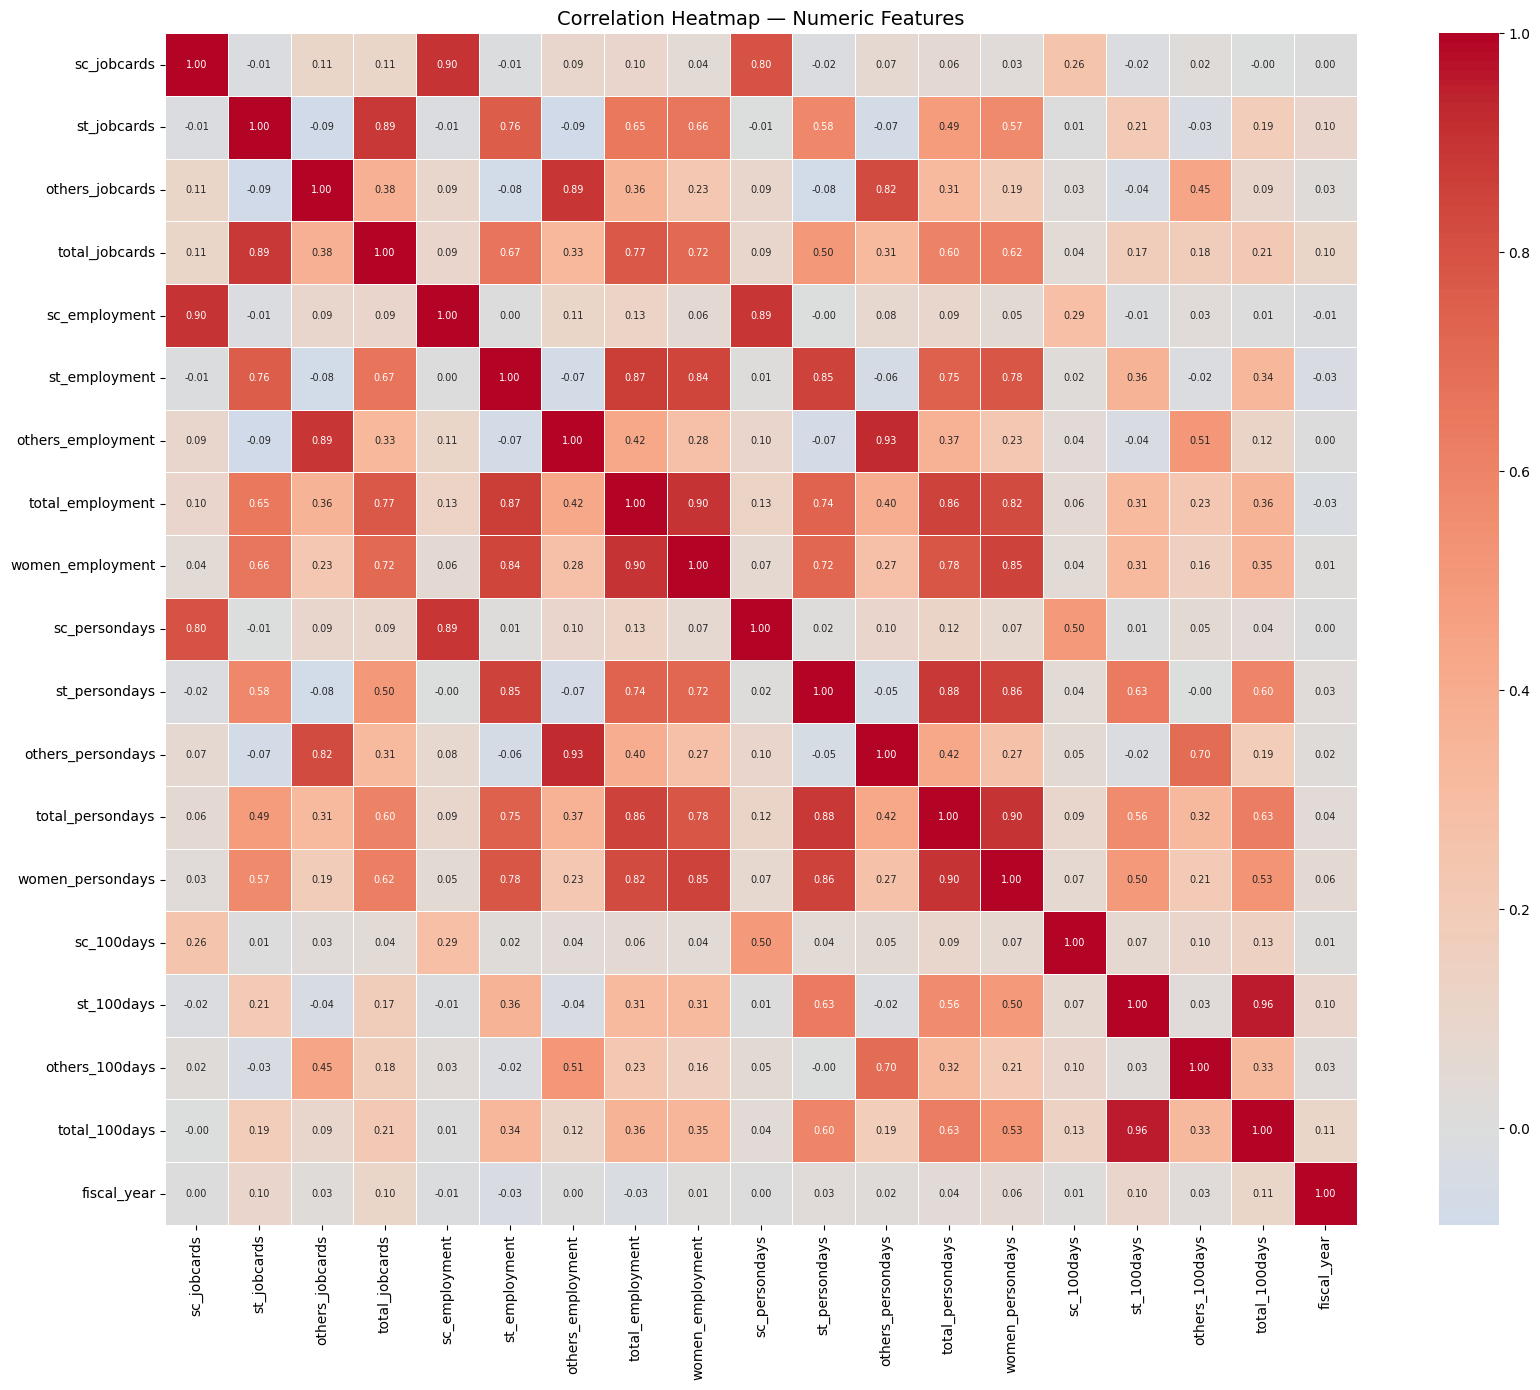

In [3]:
num_df = df.select_dtypes(include='number')
plt.figure(figsize=(18, 14))
sns.heatmap(
    num_df.corr(numeric_only=True),
    cmap='coolwarm',
    center=0,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 7},
    square=True,
    linewidths=0.5
)
plt.title('Correlation Heatmap — Numeric Features', fontsize=14)
plt.tight_layout()

plt.show()

In [4]:
# NEVER group by 'Village Name' alone — many names repeat across
# different District/Block combos (confirmed earlier: 1,049 of 5,990
# names span multiple districts/blocks, e.g. 'mawlong' = 6 distinct villages).
# This composite key is the correct unique village identifier.

village_key_cols = ['District', 'Block', 'Village Name']

n_villages = df.groupby(village_key_cols).ngroups
print(f"Unique villages (correct key): {n_villages}")

# Sort chronologically WITHIN each village — required before any lag/shift logic.
# Since there's no missing-data gaps (confirmed earlier), row order after this
# sort = true calendar order per village.
df = df.sort_values(village_key_cols + ['fiscal_year']).reset_index(drop=True)

Unique villages (correct key): 7273


In [5]:
# Access rate = share of job-card-holding households that actually got work.
# Denominator can legitimately be 0 (no ST job cards issued that year in that
# village) — replace 0 with NaN so we get NaN (unknown/not applicable) instead
# of a divide-by-zero error or a misleading 0% for villages with no ST population.
df['sc_access_rate'] = df['sc_employment'] / df['sc_jobcards'].replace(0, np.nan)
df['st_access_rate'] = df['st_employment'] / df['st_jobcards'].replace(0, np.nan)
df['others_access_rate'] = df['others_employment'] / df['others_jobcards'].replace(0, np.nan)

# Persondays per employed household — captures WORK VOLUME, a signal distinct
# from access rate (a household can count as "employed" but receive very
# little actual work).
df['st_persondays_per_employed'] = df['st_persondays'] / df['st_employment'].replace(0, np.nan)
df['sc_persondays_per_employed'] = df['sc_persondays'] / df['sc_employment'].replace(0, np.nan)
df['others_persondays_per_employed'] = df['others_persondays'] / df['others_employment'].replace(0, np.nan)

# 100-day completion rate — stricter measure than "employed or not";
# tracks the fraction of ST job-card households that got the FULL
# guaranteed 100 days of work.
df['st_100days_rate'] = df['st_100days'] / df['st_jobcards'].replace(0, np.nan)
df['sc_100days_rate'] = df['sc_100days'] / df['sc_jobcards'].replace(0, np.nan)

# ST share of total job cards — proxy for how "ST-heavy" a village's
# population is; useful context feature even though it's weakly correlated
# with access rate on its own (confirmed earlier via heatmap).
df['st_share_of_jobcards'] = df['st_jobcards'] / df['total_jobcards'].replace(0, np.nan)

# Gap ratio — ST access relative to Others' access in the same village-year.
df['st_gap_ratio'] = df['st_access_rate'] / df['others_access_rate'].replace(0, np.nan)

print("Derived rate features added:")
print(df[['st_access_rate', 'st_persondays_per_employed', 'st_100days_rate',
          'st_share_of_jobcards', 'st_gap_ratio']].describe())

Derived rate features added:
       st_access_rate  st_persondays_per_employed  st_100days_rate  st_share_of_jobcards  st_gap_ratio
count    55885.000000                46544.000000     55885.000000          56562.000000  15299.000000
mean         0.743496                   69.883072         0.247199              0.961051      1.018171
std          0.368484                   28.616521         0.492599              0.148161      0.519400
min          0.000000                    1.000000         0.000000              0.000000      0.000000
25%          0.695652                   47.041250         0.000000              0.982609      0.924449
50%          0.928571                   77.467708         0.000000              1.000000      0.986667
75%          1.000000                   97.391304         0.494737              1.000000      1.000000
max          2.944444                  111.555556        44.000000              1.000000     23.400000


In [6]:
# Lag features MUST be computed on the full sorted history per village,
# using .shift(), which only pulls from STRICTLY EARLIER rows for that
# village's group — this is what keeps these features leakage-free.
# (Correct only because Step 2 already sorted by village + fiscal_year.)

# 1-year, 2-year, and 3-year lag of ST access rate
df['st_access_rate_lag1'] = df.groupby(village_key_cols)['st_access_rate'].shift(1)
df['st_access_rate_lag2'] = df.groupby(village_key_cols)['st_access_rate'].shift(2)
df['st_access_rate_lag3'] = df.groupby(village_key_cols)['st_access_rate'].shift(3)

# Year-over-year change (trend direction) — is the village improving or declining?
df['st_access_rate_change'] = df['st_access_rate_lag1'] - df.groupby(village_key_cols)['st_access_rate'].shift(2)

# Lag of persondays-per-employed and 100-day rate — same logic, prior years only
df['st_persondays_per_employed_lag1'] = df.groupby(village_key_cols)['st_persondays_per_employed'].shift(1)
df['st_100days_rate_lag1'] = df.groupby(village_key_cols)['st_100days_rate'].shift(1)

# Rolling 3-year average of ST access rate, using ONLY prior years
# (shift(1) first, then roll — this keeps the current year fully excluded)
df['st_access_rate_roll3'] = (
    df.groupby(village_key_cols)['st_access_rate']
      .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
)

print("Lag features added. Sample for one village:")
print(df[village_key_cols + ['fiscal_year', 'st_access_rate', 'st_access_rate_lag1',
                               'st_access_rate_lag2', 'st_access_rate_roll3']].head(10))

Lag features added. Sample for one village:
          District           Block  Village Name  fiscal_year  st_access_rate  st_access_rate_lag1  st_access_rate_lag2  st_access_rate_roll3
0  East Garo Hills  Dambo Rongjeng  ambare ading         2014             NaN                  NaN                  NaN                   NaN
1  East Garo Hills  Dambo Rongjeng  ambare ading         2015             NaN                  NaN                  NaN                   NaN
2  East Garo Hills  Dambo Rongjeng  ambare ading         2016        0.000000                  NaN                  NaN                   NaN
3  East Garo Hills  Dambo Rongjeng  ambare ading         2017        1.000000             0.000000                  NaN              0.000000
4  East Garo Hills  Dambo Rongjeng  ambare ading         2018        0.929825             1.000000             0.000000              0.500000
5  East Garo Hills  Dambo Rongjeng  ambare ading         2019        0.904762             0.929825      

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


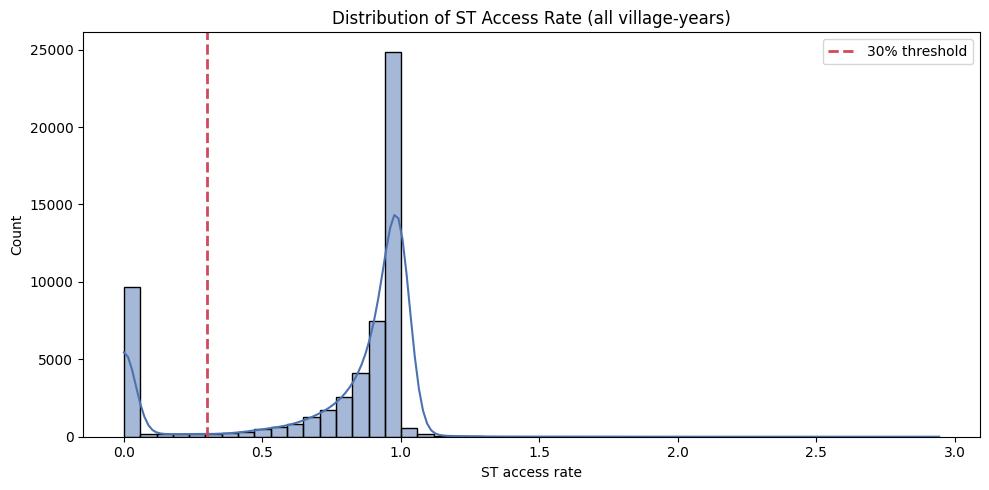

count    55885.000
mean         0.743
std          0.368
min          0.000
25%          0.696
50%          0.929
75%          1.000
max          2.944
Name: st_access_rate, dtype: float64


In [8]:
plt.figure(figsize=(10, 5))
sns.histplot(df['st_access_rate'].dropna(), bins=50, color='#4C72B0', kde=True)
plt.axvline(0.30, color='#D1495B', linestyle='--', linewidth=2, label='30% threshold')
plt.title('Distribution of ST Access Rate (all village-years)')
plt.xlabel('ST access rate')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig('st_access_distribution.png', dpi=200, bbox_inches='tight')
plt.show()

print(df['st_access_rate'].describe().round(3))

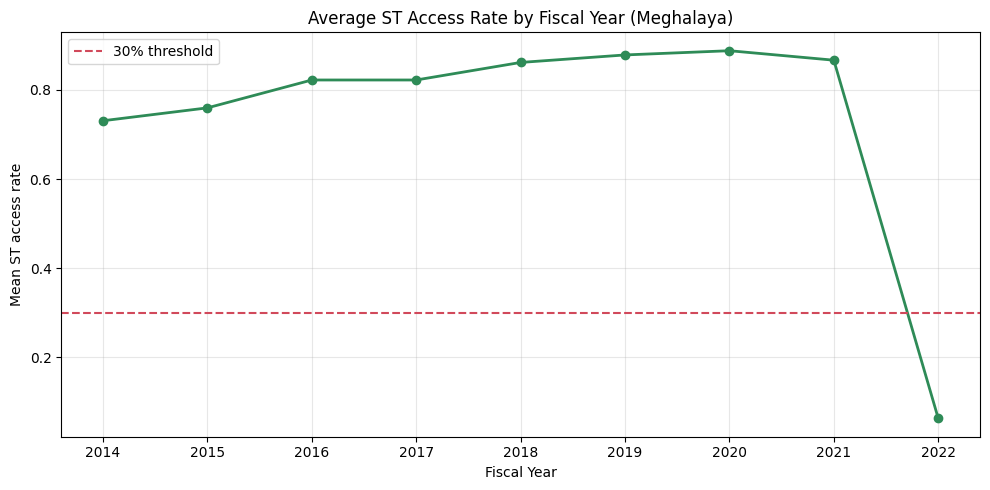

In [9]:
yearly = df.groupby('fiscal_year')['st_access_rate'].mean()

plt.figure(figsize=(10, 5))
plt.plot(yearly.index, yearly.values, marker='o', color='#2E8B57', linewidth=2)
plt.axhline(0.30, color='#D1495B', linestyle='--', label='30% threshold')
plt.title('Average ST Access Rate by Fiscal Year (Meghalaya)')
plt.xlabel('Fiscal Year')
plt.ylabel('Mean ST access rate')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('st_access_by_year.png', dpi=200, bbox_inches='tight')
plt.show()

In [10]:
# Label: is THIS village-year a "low access" year for ST households?
# Threshold matches your corrected analysis: access rate < 30%.
df['is_low_access_current'] = (df['st_access_rate'] < 0.30).astype(int)

# Also build the lag version of the label — useful as a feature itself
# ("was this village low-access last year?"), NOT as the target.
df['is_low_access_lag1'] = (df['st_access_rate_lag1'] < 0.30).astype(int)

# Sanity checks — should match what you already verified earlier
print(f"Overall positive class rate: {df['is_low_access_current'].mean()*100:.2f}%")
print(f"\nLabel distribution:")
print(df['is_low_access_current'].value_counts())

# Confirm no leakage: label uses ONLY current-year access rate,
# lag/rolling features use ONLY shifted (prior-year) values — verified
# by construction in Step 4, since every _lag and _roll3 column is
# built with .shift() before any aggregation.

Overall positive class rate: 17.91%

Label distribution:
is_low_access_current
0    47478
1    10357
Name: count, dtype: int64


/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less
  return op(a, b)


In [11]:
# ============================================================
# ONE CELL: drop bad 2022 year -> clean split -> XGBoost -> compare to naive
# ============================================================
import xgboost as xgb


target = 'is_low_access_current'

# 1) Drop corrupted 2022 (86% of villages show exactly 0 access = data artifact)
df_clean = df[df['fiscal_year'] <= 2021].copy()

# 2) Year/district context features (previous year only)
df_clean = df_clean.drop(columns=['national_low_rate_prev', 'district_low_rate_prev'], errors='ignore')
yr = (df_clean.groupby('fiscal_year')[target].mean()
        .rename('national_low_rate_prev').shift(1).reset_index())
dist_yr = (df_clean.groupby(['District', 'fiscal_year'])[target].mean()
             .rename('district_low_rate_prev')
             .groupby(level=0).shift(1).reset_index())
df_clean = df_clean.merge(yr, on='fiscal_year', how='left')
df_clean = df_clean.merge(dist_yr, on=['District', 'fiscal_year'], how='left')

model_df = df_clean.dropna(subset=['st_access_rate_lag1', target]).copy()
assert model_df['fiscal_year'].max() == 2021, "2022 still present!"

# 3) Split by time
train_df = model_df[model_df.fiscal_year <= 2018]
val_df   = model_df[model_df.fiscal_year.isin([2019, 2020])]
test_df  = model_df[model_df.fiscal_year == 2021]
for name, d in [('train', train_df), ('val', val_df), ('test', test_df)]:
    print(f"{name}: {len(d)} rows, years {d.fiscal_year.min()}-{d.fiscal_year.max()}, "
          f"positive rate {d[target].mean():.3f}")

# 4) Features
numeric_features = [
    'st_access_rate_lag1', 'st_access_rate_lag2', 'st_access_rate_lag3',
    'st_access_rate_change', 'st_access_rate_roll3',
    'st_persondays_per_employed_lag1', 'st_100days_rate_lag1',
    'st_share_of_jobcards', 'is_low_access_lag1',
    'national_low_rate_prev', 'district_low_rate_prev',
]
categorical_features = ['District', 'Block']
all_features = numeric_features + categorical_features

def prep(d, cols=None):
    X = pd.get_dummies(d[all_features], columns=categorical_features)
    return X if cols is None else X.reindex(columns=cols, fill_value=0)

X_train = prep(train_df); cols = X_train.columns
X_val, X_test = prep(val_df, cols), prep(test_df, cols)
y_train, y_val, y_test = train_df[target], val_df[target], test_df[target]
spw = (y_train == 0).sum() / (y_train == 1).sum()

# 5) Tune XGBoost
order = train_df['fiscal_year'].values.argsort(kind='stable')
search = RandomizedSearchCV(
    xgb.XGBClassifier(objective='binary:logistic', scale_pos_weight=spw,
                      eval_metric='aucpr', random_state=42, n_jobs=-1),
    param_distributions={
        'n_estimators': [200, 400, 600], 'max_depth': [3, 4, 5, 6],
        'learning_rate': [0.01, 0.03, 0.05, 0.1], 'subsample': [0.7, 0.8, 0.9, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0], 'min_child_weight': [1, 3, 5, 7],
        'reg_lambda': [1, 2, 3]},
    n_iter=30, scoring='average_precision',
    cv=TimeSeriesSplit(n_splits=3), random_state=42, n_jobs=-1, verbose=0)
search.fit(X_train.iloc[order], y_train.iloc[order])
model = search.best_estimator_
print("\nBest params:", search.best_params_)

# 6) Threshold from validation years, evaluate on 2021
p_val = model.predict_proba(X_val)[:, 1]
prec, rec, thr = precision_recall_curve(y_val, p_val)
best_thr = thr[(2*prec[:-1]*rec[:-1] / (prec[:-1]+rec[:-1]+1e-9)).argmax()]
p_test = model.predict_proba(X_test)[:, 1]
pred = (p_test >= best_thr).astype(int)

print(f"\n=== XGBoost on clean 2021 test ===")
print(f"PR-AUC {average_precision_score(y_test, p_test):.3f}  (random baseline = {y_test.mean():.3f})")
print(f"Recall {recall_score(y_test, pred):.3f}  Precision {precision_score(y_test, pred):.3f}  F1 {f1_score(y_test, pred):.3f}")

naive = test_df['is_low_access_lag1'].values
print(f"\n=== Naive rule: 'low last year -> low this year' ===")
print(f"Recall {recall_score(y_test, naive):.3f}  Precision {precision_score(y_test, naive):.3f}  F1 {f1_score(y_test, naive):.3f}")

train: 24230 rows, years 2015-2018, positive rate 0.101
val: 12179 rows, years 2019-2020, positive rate 0.040
test: 6194 rows, years 2021-2021, positive rate 0.056

Best params: {'subsample': 0.9, 'reg_lambda': 3, 'n_estimators': 600, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.01, 'colsample_bytree': 0.6}

=== XGBoost on clean 2021 test ===
PR-AUC 0.394  (random baseline = 0.056)
Recall 0.249  Precision 0.623  F1 0.356

=== Naive rule: 'low last year -> low this year' ===
Recall 0.336  Precision 0.498  F1 0.401


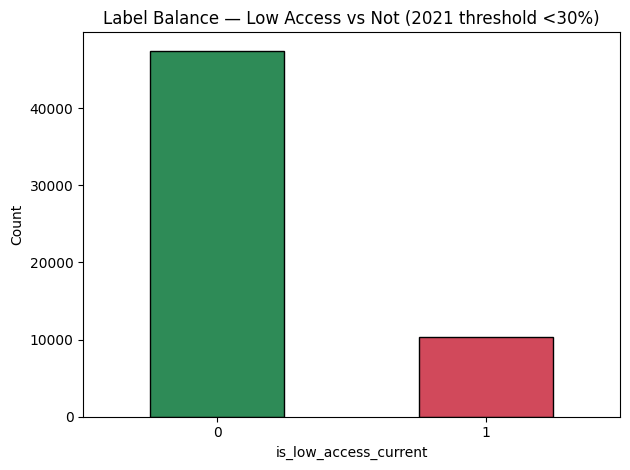

is_low_access_current
0    82.1
1    17.9
Name: proportion, dtype: float64


In [19]:
df['is_low_access_current'].value_counts().plot(
    kind='bar', color=['#2E8B57', '#D1495B'], edgecolor='black'
)
plt.title('Label Balance — Low Access vs Not (2021 threshold <30%)')
plt.xlabel('is_low_access_current')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('label_balance.png', dpi=200, bbox_inches='tight')
plt.show()

print(df['is_low_access_current'].value_counts(normalize=True).round(3) * 100)

In [12]:
# ============================================================
# LIGHTGBM on the clean split 
# ============================================================
import lightgbm as lgb


# Same time-ordered training data as XGBoost
order = train_df['fiscal_year'].values.argsort(kind='stable')
X_tr_s, y_tr_s = X_train.iloc[order], y_train.iloc[order]

lgb_search = RandomizedSearchCV(
    lgb.LGBMClassifier(objective='binary', scale_pos_weight=spw,
                       random_state=42, n_jobs=1, verbose=-1),
    param_distributions={
        'n_estimators': [200, 400, 600],
        'num_leaves': [15, 31, 50],
        'max_depth': [-1, 4, 6, 8],
        'learning_rate': [0.01, 0.03, 0.05, 0.1],
        'subsample': [0.7, 0.8, 0.9, 1.0],
        'subsample_freq': [1],            # required, otherwise subsample is ignored
        'colsample_bytree': [0.6, 0.8, 1.0],
        'min_child_samples': [10, 20, 50],
        'reg_alpha': [0, 0.1, 1],
        'reg_lambda': [0, 0.1, 1],
    },
    n_iter=30, scoring='average_precision',
    cv=TimeSeriesSplit(n_splits=3), random_state=42, n_jobs=-1, verbose=0)

lgb_search.fit(X_tr_s, y_tr_s)
best_lgb = lgb_search.best_estimator_
print("Best LGBM params:", lgb_search.best_params_)

# Evaluate on clean 2021 test, same way as XGBoost
p_lgb = best_lgb.predict_proba(X_test)[:, 1]
print(f"\nLightGBM test PR-AUC: {average_precision_score(y_test, p_lgb):.3f}")
print(f"XGBoost  test PR-AUC: {average_precision_score(y_test, p_test):.3f}")

# Recall if officers review top K%
for name, p in [('XGBoost', p_test), ('LightGBM', p_lgb)]:
    o = np.argsort(-p)
    print(f"\n{name}:")
    for k in [5, 10, 20, 30]:
        n = int(len(p) * k / 100)
        print(f"  top {k:>2}%: recall {y_test.values[o[:n]].sum() / y_test.sum():.1%}")

Best LGBM params: {'subsample_freq': 1, 'subsample': 1.0, 'reg_lambda': 1, 'reg_alpha': 0, 'num_leaves': 31, 'n_estimators': 400, 'min_child_samples': 50, 'max_depth': 6, 'learning_rate': 0.01, 'colsample_bytree': 0.6}

LightGBM test PR-AUC: 0.393
XGBoost  test PR-AUC: 0.394

XGBoost:
  top  5%: recall 37.1%
  top 10%: recall 51.0%
  top 20%: recall 71.6%
  top 30%: recall 81.4%

LightGBM:
  top  5%: recall 38.8%
  top 10%: recall 51.6%
  top 20%: recall 70.1%
  top 30%: recall 80.6%


In [13]:
# ============================================================
# CATBOOST on the clean split 
# ============================================================
from catboost import CatBoostClassifier


# CatBoost takes RAW District/Block (not one-hot), sorted by year for chronological CV
train_sorted = train_df.sort_values('fiscal_year')
Xc_train, yc_train = train_sorted[all_features], train_sorted[target]
Xc_test = test_df[all_features]

cat_search = RandomizedSearchCV(
    CatBoostClassifier(loss_function='Logloss', scale_pos_weight=spw,
                       cat_features=categorical_features,
                       random_state=42, verbose=False, thread_count=2),
    param_distributions={
        'iterations': [300, 500, 800],
        'depth': [4, 6, 8],
        'learning_rate': [0.03, 0.05, 0.1],
        'l2_leaf_reg': [1, 3, 5, 9],
        'border_count': [64, 128],
    },
    n_iter=10, scoring='average_precision',
    cv=TimeSeriesSplit(n_splits=3), random_state=42,
    n_jobs=1, verbose=1)

cat_search.fit(Xc_train, yc_train)
best_cat = cat_search.best_estimator_
print("Best CatBoost params:", cat_search.best_params_)

p_cat = best_cat.predict_proba(Xc_test)[:, 1]
print(f"\nCatBoost test PR-AUC: {average_precision_score(y_test, p_cat):.3f}")
print(f"XGBoost  test PR-AUC: {average_precision_score(y_test, p_test):.3f}")

for name, p in [('XGBoost', p_test), ('LightGBM', p_lgb), ('CatBoost', p_cat)]:
    o = np.argsort(-p)
    print(f"\n{name}:")
    for k in [5, 10, 20, 30]:
        n = int(len(p) * k / 100)
        print(f"  top {k:>2}%: recall {y_test.values[o[:n]].sum() / y_test.sum():.1%}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best CatBoost params: {'learning_rate': 0.05, 'l2_leaf_reg': 1, 'iterations': 800, 'depth': 8, 'border_count': 128}

CatBoost test PR-AUC: 0.319
XGBoost  test PR-AUC: 0.394

XGBoost:
  top  5%: recall 37.1%
  top 10%: recall 51.0%
  top 20%: recall 71.6%
  top 30%: recall 81.4%

LightGBM:
  top  5%: recall 38.8%
  top 10%: recall 51.6%
  top 20%: recall 70.1%
  top 30%: recall 80.6%

CatBoost:
  top  5%: recall 35.1%
  top 10%: recall 45.5%
  top 20%: recall 58.6%
  top 30%: recall 65.5%


In [14]:
# ============================================================
# ABLATION: fix NaN + drop year-fingerprint features
# ============================================================



def run(feats_num, fill_pd0=False, label=''):
    tr, te = train_df.copy(), test_df.copy()
    if fill_pd0:
        for d in (tr, te):
            d['st_persondays_per_employed_lag1'] = d['st_persondays_per_employed_lag1'].fillna(0)
    feats = feats_num + categorical_features
    Xtr = pd.get_dummies(tr[feats], columns=categorical_features)
    Xte = pd.get_dummies(te[feats], columns=categorical_features).reindex(columns=Xtr.columns, fill_value=0)
    m = xgb.XGBClassifier(**search.best_params_, objective='binary:logistic',
            scale_pos_weight=(tr[target]==0).sum()/(tr[target]==1).sum(),
            random_state=42, n_jobs=-1).fit(Xtr, tr[target])
    p = m.predict_proba(Xte)[:, 1]
    o = np.argsort(-p); n20 = int(len(p) * 0.2)
    print(f"{label:38s} PR-AUC {average_precision_score(te[target], p):.3f} | "
          f"recall@top20% {te[target].values[o[:n20]].sum()/te[target].sum():.1%}")

base = [f for f in numeric_features]
no_year = [f for f in base if f not in ('national_low_rate_prev', 'district_low_rate_prev')]

run(base,    False, 'A) current (baseline)')
run(base,    True,  'B) persondays NaN -> 0')
run(no_year, True,  'C) B + drop year/district-rate feats')

A) current (baseline)                  PR-AUC 0.393 | recall@top20% 70.1%
B) persondays NaN -> 0                 PR-AUC 0.393 | recall@top20% 69.9%
C) B + drop year/district-rate feats   PR-AUC 0.407 | recall@top20% 73.9%


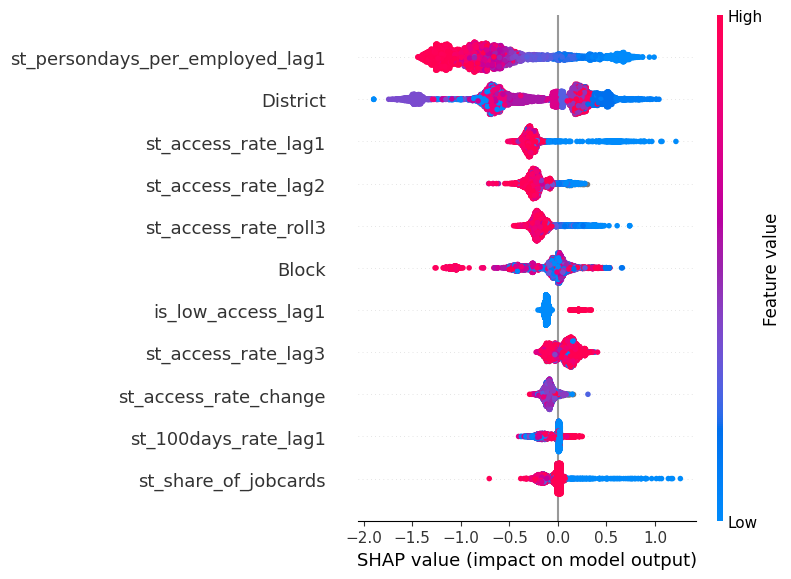

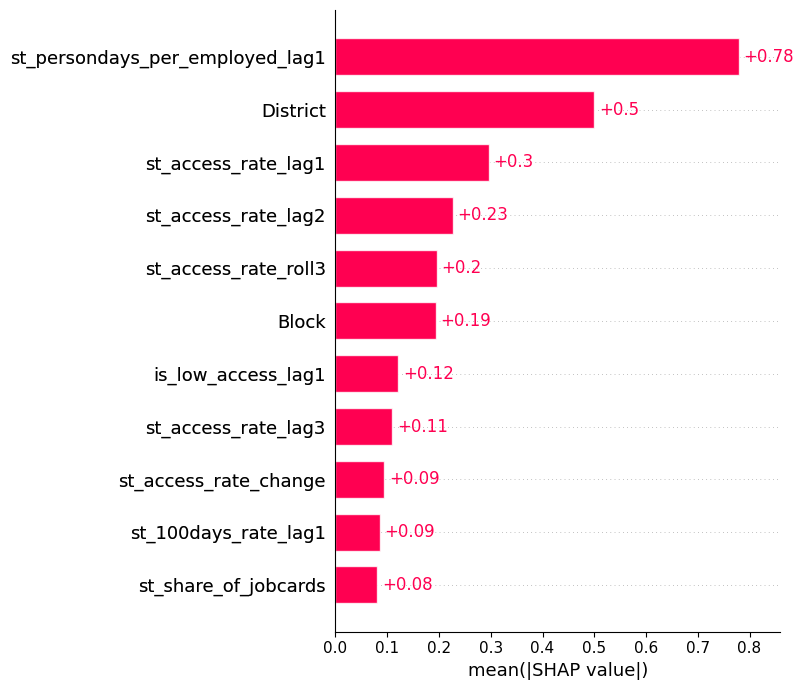

Highest-risk village: bomboithol | East Jaintia Hills / Saipung | risk 95.4% | ST job cards last year: check st_jobcards=18.0


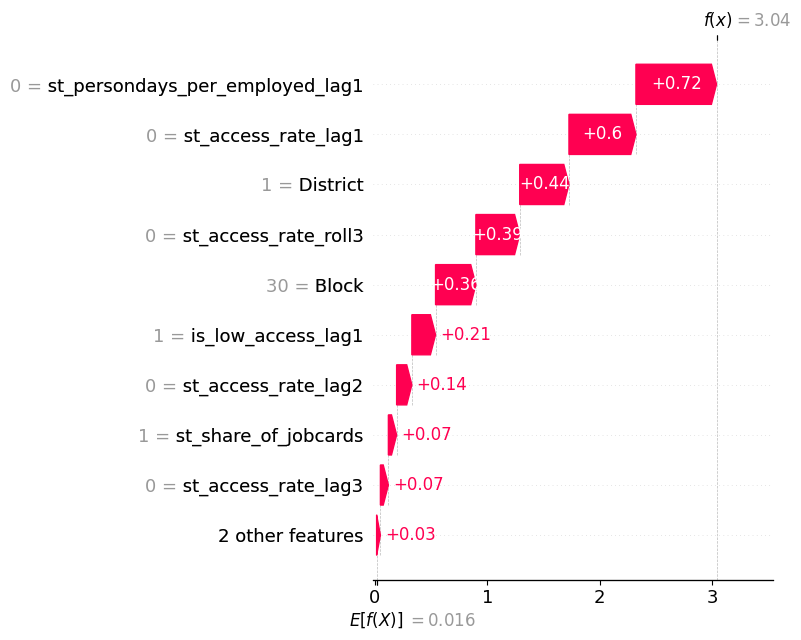

In [15]:
# ============================================================
# FINAL MODEL (version C) + SHAP
# ============================================================
import shap

final_num = [f for f in numeric_features
             if f not in ('national_low_rate_prev', 'district_low_rate_prev')]
feats = final_num + categorical_features

tr, te = train_df.copy(), test_df.copy()
for d in (tr, te):
    d['st_persondays_per_employed_lag1'] = d['st_persondays_per_employed_lag1'].fillna(0)

Xtr = pd.get_dummies(tr[feats], columns=categorical_features)
Xte = pd.get_dummies(te[feats], columns=categorical_features).reindex(columns=Xtr.columns, fill_value=0)

final_model = xgb.XGBClassifier(**search.best_params_, objective='binary:logistic',
        scale_pos_weight=(tr[target]==0).sum()/(tr[target]==1).sum(),
        random_state=42, n_jobs=-1).fit(Xtr, tr[target])

sv = shap.TreeExplainer(final_model)(Xte)

# group District_*/Block_* dummies back into single features
groups = {}
for i, c in enumerate(Xte.columns):
    g = 'District' if c.startswith('District_') else 'Block' if c.startswith('Block_') else c
    groups.setdefault(g, []).append(i)
vals = np.column_stack([sv.values[:, ix].sum(axis=1) for ix in groups.values()])
data = np.column_stack([Xte.iloc[:, ix].values.argmax(axis=1) if len(ix) > 1
                        else Xte.iloc[:, ix[0]].values for ix in groups.values()])
svg = shap.Explanation(values=vals, base_values=sv.base_values,
                       data=data, feature_names=list(groups.keys()))

shap.plots.beeswarm(svg, max_display=12, show=False); plt.tight_layout()
plt.savefig('shap_global_C.png', dpi=200, bbox_inches='tight'); plt.show()

shap.plots.bar(svg, max_display=12, show=False); plt.tight_layout()
plt.savefig('shap_bar_C.png', dpi=200, bbox_inches='tight'); plt.show()

p = final_model.predict_proba(Xte)[:, 1]
top = int(np.argmax(p)); v = te.iloc[top]
print(f"Highest-risk village: {v['Village Name']} | {v['District']} / {v['Block']} | "
      f"risk {p[top]:.1%} | ST job cards last year: check st_jobcards={v['st_jobcards']}")
shap.plots.waterfall(svg[top], max_display=10, show=False); plt.tight_layout()
plt.savefig('shap_village_C.png', dpi=200, bbox_inches='tight'); plt.show()

In [16]:
# ============================================================
# EXPORT: ranked 2021 villages + top-3 reasons for the Streamlit app
# ============================================================
# Rebuild 2021 test matrix to match final_model exactly


te = test_df.copy()
te['st_persondays_per_employed_lag1'] = te['st_persondays_per_employed_lag1'].fillna(0)
Xte = (pd.get_dummies(te[feats], columns=categorical_features)
         .reindex(columns=final_model.get_booster().feature_names, fill_value=0))
p = final_model.predict_proba(Xte)[:, 1]

out = te[['District', 'Block', 'Village Name', 'st_jobcards', 'st_access_rate_lag1',
          'st_access_rate_roll3', 'st_persondays_per_employed_lag1',
          'st_100days_rate_lag1', 'is_low_access_lag1', target]].copy()
out['risk'] = p
out = out.reset_index(drop=True)

labels = {'st_access_rate_lag1': "Last year's ST access rate",
          'st_access_rate_lag2': "ST access rate two years ago",
          'st_access_rate_lag3': "ST access rate three years ago",
          'st_access_rate_roll3': "3-year average ST access rate",
          'st_access_rate_change': "Year-on-year change in access",
          'st_persondays_per_employed_lag1': "Workdays per employed household last year",
          'st_100days_rate_lag1': "Share completing 100 days last year",
          'st_share_of_jobcards': "ST share of job cards",
          'is_low_access_lag1': "Was low-access last year",
          'District': "District pattern", 'Block': "Block pattern"}
names = svg.feature_names

def reasons(i, k=3):
    idx = np.argsort(-np.abs(svg.values[i]))[:k]
    return " | ".join(f"{labels.get(names[j], names[j])} "
                      f"({'raises' if svg.values[i, j] > 0 else 'lowers'} risk)" for j in idx)

out['reasons'] = [reasons(i) for i in range(len(out))]
out.to_csv('village_risk_2021.csv', index=False)
print(out.shape, '-> saved village_risk_2021.csv')

(6194, 12) -> saved village_risk_2021.csv


In [17]:
rows = []
for ty in [2018, 2019, 2020, 2021]:
    tr = model_df[model_df.fiscal_year < ty].copy()
    te = model_df[model_df.fiscal_year == ty].copy()
    for d in (tr, te):
        d['st_persondays_per_employed_lag1'] = d['st_persondays_per_employed_lag1'].fillna(0)
    Xtr = pd.get_dummies(tr[feats], columns=categorical_features)
    Xte = pd.get_dummies(te[feats], columns=categorical_features).reindex(columns=Xtr.columns, fill_value=0)
    m = xgb.XGBClassifier(**search.best_params_, objective='binary:logistic',
            scale_pos_weight=(tr[target]==0).sum()/(tr[target]==1).sum(),
            random_state=42, n_jobs=-1).fit(Xtr, tr[target])
    p = m.predict_proba(Xte)[:, 1]
    o = np.argsort(-p); n20 = int(len(p) * 0.2)
    naive = te['is_low_access_lag1'].values
    rows.append({'test_year': ty,
                 'base_rate': te[target].mean(),
                 'xgb_pr_auc': average_precision_score(te[target], p),
                 'xgb_recall@top20%': te[target].values[o[:n20]].sum() / te[target].sum(),
                 'naive_recall': recall_score(te[target], naive)})
print(pd.DataFrame(rows).round(3).to_string(index=False))

 test_year  base_rate  xgb_pr_auc  xgb_recall@top20%  naive_recall
      2018      0.058       0.381              0.760         0.563
      2019      0.042       0.361              0.736         0.496
      2020      0.037       0.438              0.763         0.496
      2021      0.056       0.415              0.719         0.336


In [18]:
# ============================================================
# RECALL-FIRST: threshold sweep + recall targets + naive comparison
# ============================================================


p_test = model.predict_proba(X_test)[:, 1]
naive = test_df['is_low_access_lag1'].values

# 1) Sweep thresholds on 2021 test (for the pitch table; not for tuning)
rows = []
for t in [0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5, 0.6, 0.756]:
    pred = (p_test >= t).astype(int)
    rows.append({'threshold': t,
                 'recall': recall_score(y_test, pred),
                 'precision': precision_score(y_test, pred, zero_division=0),
                 'villages_flagged': int(pred.sum()),
                 'pct_flagged': pred.mean() * 100})
print(pd.DataFrame(rows).round(3).to_string(index=False))

# 2) Threshold chosen on VALIDATION to hit a recall target (honest, no peeking at 2021)
p_val = model.predict_proba(X_val)[:, 1]
prec_v, rec_v, thr_v = precision_recall_curve(y_val, p_val)
print("\n=== Threshold set on 2019-2020 val for recall target, applied to 2021 ===")
for target_recall in [0.6, 0.7, 0.8]:
    ok = np.where(rec_v[:-1] >= target_recall)[0]
    t = thr_v[ok[-1]]
    pred = (p_test >= t).astype(int)
    print(f"target {target_recall:.0%} -> thr {t:.3f} | test recall {recall_score(y_test, pred):.3f}, "
          f"precision {precision_score(y_test, pred):.3f}, flagged {pred.mean()*100:.1f}% of villages")

# 3) Naive rule for comparison
print(f"\nNaive rule: recall {recall_score(y_test, naive):.3f}, precision {precision_score(y_test, naive):.3f}, "
      f"flagged {naive.mean()*100:.1f}%")

# 4) Recall at fixed review budget: "officers can visit the top K% of villages"
order = np.argsort(-p_test)
print("\n=== Recall if officers review only the top K% (ranked by model) ===")
for k in [5, 10, 15, 20, 30]:
    n = int(len(p_test) * k / 100)
    caught = y_test.values[order[:n]].sum()
    print(f"top {k:>2}% ({n} villages): catches {caught/y_test.sum():.1%} of low-access villages, "
          f"precision {caught/n:.1%}")

 threshold  recall  precision  villages_flagged  pct_flagged
     0.050   0.991      0.076              4517       72.925
     0.100   0.893      0.115              2669       43.090
     0.150   0.780      0.167              1609       25.977
     0.200   0.696      0.203              1184       19.115
     0.300   0.557      0.263               730       11.786
     0.400   0.464      0.316               506        8.169
     0.500   0.380      0.398               329        5.312
     0.600   0.330      0.498               229        3.697
     0.756   0.249      0.623               138        2.228

=== Threshold set on 2019-2020 val for recall target, applied to 2021 ===
target 60% -> thr 0.396 | test recall 0.467, precision 0.313, flagged 8.3% of villages
target 70% -> thr 0.243 | test recall 0.635, precision 0.232, flagged 15.3% of villages
target 80% -> thr 0.162 | test recall 0.765, precision 0.177, flagged 24.1% of villages

Naive rule: recall 0.336, precision 0.498, flagged 